In [1]:
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
stk_data=pd.read_csv("Tatacoffee13_21.csv",parse_dates=['Date'],index_col='Date')

In [7]:
stk_data

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [9]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2225 entries, 2013-01-01 to 2021-12-28
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2225 non-null   float64
 1   High    2225 non-null   float64
 2   Low     2225 non-null   float64
 3   Close   2225 non-null   float64
dtypes: float64(4)
memory usage: 86.9 KB


In [11]:
column="Close"

In [13]:
from sklearn.preprocessing import MinMaxScaler
Ms=MinMaxScaler()
data1=Ms.fit_transform(stk_data[[column]])

In [14]:
training_size=round(len(data1)*0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [45]:
orders=[(1,1,1),(1,1,2),(2,1,1),(2,1,2)]
#orderslist=[]
#rscorelist=[]
for i in orders:
    #orderslist.append(i)
    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(X_train, order=i)
    model_fit = model.fit()
    # make prediction
    y_pred= model_fit.predict(len(X_train), len(data1)-1)
    #print(y_pred)
    print("Order={}".format(i))
    from stockFunctions import rmsemape
    rmsemape(y_test,y_pred)
    print("*********")

Order=(1, 1, 1)
RMSE-Testset: 0.054212422123834474
maPe-Testset: 110244145198.1096
*********
Order=(1, 1, 2)
RMSE-Testset: 0.05409842654471195
maPe-Testset: 111417589027.02234
*********
Order=(2, 1, 1)
RMSE-Testset: 0.05407475032379553
maPe-Testset: 111806961871.4761
*********
Order=(2, 1, 2)
RMSE-Testset: 0.05412796900466933
maPe-Testset: 111296712405.7001
*********


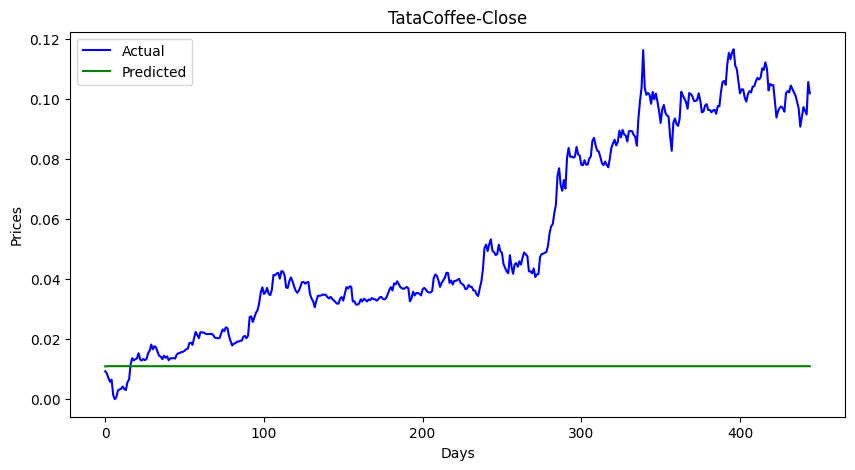

In [47]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close","Days","Prices")

In [49]:
len(data1)

2225

In [51]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [53]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

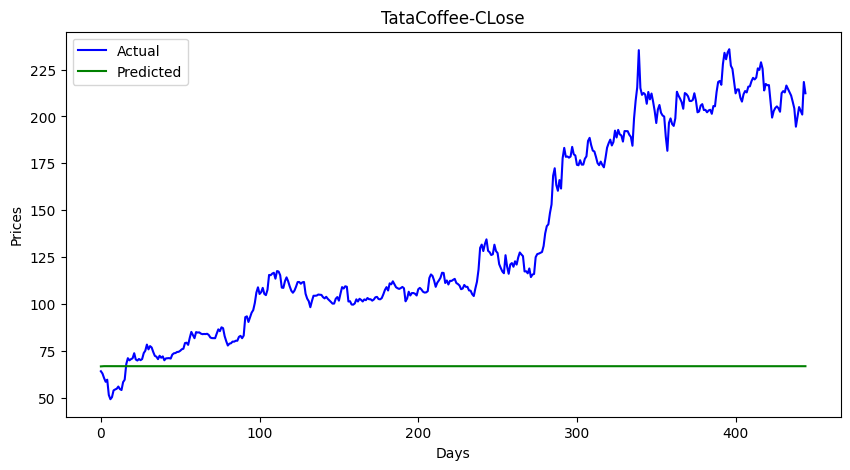

In [55]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-CLose","Days","Prices")

In [57]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 86.53979684466532
maPe-Testset: 0.44044087084474626


In [59]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [61]:
forecast

array([0.01099905, 0.01099905, 0.01099905, 0.01099905])

In [63]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [65]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [67]:
forecast_stock_price_test_oriF

,Closefore
0,66.985276
1,66.985276
2,66.985276
3,66.985276
